In [3]:
# importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
#Fetching S&P 500 data for the last 25 years

ticker = '^GSPC'

raw_data = yf.download(ticker, start = '2000-01-01', end = '2025-12-31')

print(raw_data.head())
print(raw_data.describe())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2000-01-03  1455.219971  1478.000000  1438.359985  1469.250000   931800000
2000-01-04  1399.420044  1455.219971  1397.430054  1455.219971  1009000000
2000-01-05  1402.109985  1413.270020  1377.680054  1399.420044  1085500000
2000-01-06  1403.449951  1411.900024  1392.099976  1402.109985  1092300000
2000-01-07  1441.469971  1441.469971  1400.729980  1403.449951  1225200000
Price         Close         High          Low         Open        Volume
Ticker        ^GSPC        ^GSPC        ^GSPC        ^GSPC         ^GSPC
count   6538.000000  6538.000000  6538.000000  6538.000000  6.538000e+03
mean    2268.251477  2280.840280  2253.981037  2267.909380  3.418338e+09
std     1453.151935  1459.538744  1445.656398  1452.858977  1.513441e+09
min      676.530029   695.270020   

In [7]:
raw_data.columns = raw_data.columns.get_level_values(0)

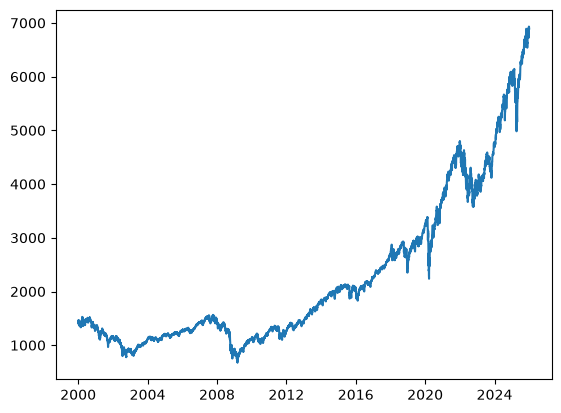

In [8]:
plt.plot(raw_data['Close'])

In [9]:
prices = raw_data['Close']

log_ret = np.log(prices / prices.shift(1)).dropna()

mean_return = log_ret.mean()
std_return = log_ret.std()

print("Mean Return:", mean_return)
print("Standard Deviation of log_ret:", std_return)

drift = mean_return - (0.5 * std_return ** 2)
print("Drift:", drift)

conf_int = 0.95

Mean Return: 0.00023800203422297205
Standard Deviation of log_ret: 0.012215594621295995
Drift: 0.00016339165824705423




Log returns are useful because:

* You can add them up over time.
* They’re easy to compare over different time periods of different lengths because they scale linearly.
* You can easily convert them into simple returns and back (see image at the top).
* They’re symmetrical on the upside and downside (if you make 10% and lose 10%, you end up at the same place.)


In [ ]:
Final_Price = prices.iloc[-1]
Final_Price = Final_Price.iloc[0]
print(Final_Price)

6896.240234375


In [ ]:
iterations = 10000
days = 21

Z = np.random.standard_normal((days, iterations))

# Convert drift and std_return from pandas Series to scalar floats
drift_scalar = drift.iloc[0]
std_return_scalar = std_return.iloc[0]

final_prices = np.exp((drift_scalar + std_return_scalar * Z).cumsum(axis = 0) + drift_scalar)

final_prices = pd.DataFrame(final_prices) * Final_Price

print(final_prices)

           0            1            2            3            4     \
0   6825.625764  6727.350864  6838.721812  6846.241721  6883.105715   
1   6982.100074  6650.611187  6908.289133  6843.742701  6788.964817   
2   6930.173855  6639.204147  6878.076257  6746.835539  6666.920036   
3   6922.494640  6681.995553  6844.916667  6698.504863  6473.566671   
4   7067.117864  6699.882757  6954.045722  6612.108007  6539.364857   
5   7204.484806  6797.973055  6685.765809  6568.890182  6531.931428   
6   7280.419375  6706.875779  6745.266180  6455.748315  6500.536012   
7   7297.818862  6687.946675  6713.364280  6529.727019  6675.268420   
8   7279.265934  6597.491212  6573.961856  6449.806104  6619.245069   
9   7450.243861  6637.620784  6636.280749  6422.253266  6502.930810   
10  7384.163460  6474.155352  6625.558887  6497.662649  6413.438313   
11  7287.946154  6568.851826  6680.878406  6399.898900  6357.776389   
12  7392.806885  6656.633313  6654.663001  6316.927914  6447.293107   
13  73

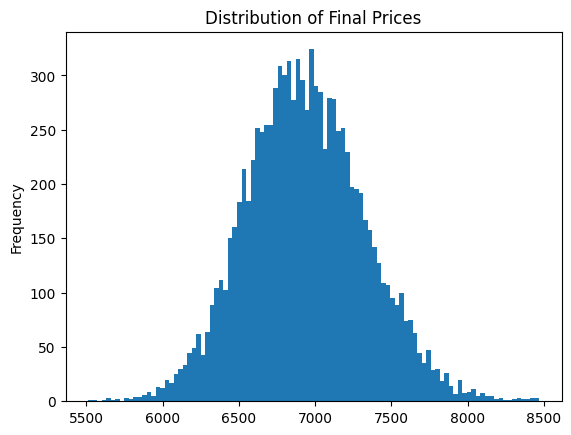

500
6326.627072494748
6165.055888963497


In [ ]:
Final_Simulated_prices = final_prices.iloc[-1]

sorted_prices = Final_Simulated_prices.sort_values()

sorted_prices.plot(kind = 'hist', bins = 100, title = 'Distribution of Final Prices')
plt.show()

Var_Index = int((1-conf) * len(sorted_prices))
print(Var_Index)

VaR = sorted_prices.iloc[int(Var_Index)]
print(VaR)

exp_sf = sorted_prices[:Var_Index].mean()
print(exp_sf)